In [41]:
import pandas as pd
import numpy as np

## Multivariate Outlier Detection
- Mahalanobis Distance (normally distributed data, low dimension)

To be studied later:
- KNN-based Outlier Detection (global outliers)
- Local Outlier Factor (local outliers)
- DBSCAN-based Outlier Detection
- One-Class SVM (high dimensional)
- Isolation Forest (high dimensional)
- PCA-based Outlier Detection

In [42]:
n_samples = 5000
outlier_frac = 0.05

n_outlier = int(n_samples * outlier_frac)
n_inliers = n_samples - n_outlier

In [43]:
mean_inliers = [0, 0]
cov_inliers = [
    [1, 0.5],
    [0.5, 1]
]

data_inliers = np.random.multivariate_normal(mean_inliers, cov_inliers, n_inliers)

In [44]:
mean_outliers = [5, 6]
cov_outliers = [
    [1, 0],
    [0, 1]
]

data_outliers = np.random.multivariate_normal(mean_outliers, cov_outliers, n_outlier)

In [45]:
data = np.concatenate([data_inliers, data_outliers], axis=0)
data = pd.DataFrame(
    data=data,
    columns=['x', 'y']
)
data.head()

,x,y
0,0.701875,0.124020
1,0.040329,-0.660972
2,1.571283,0.570625
3,-0.644780,0.863571
4,1.415705,-0.342848


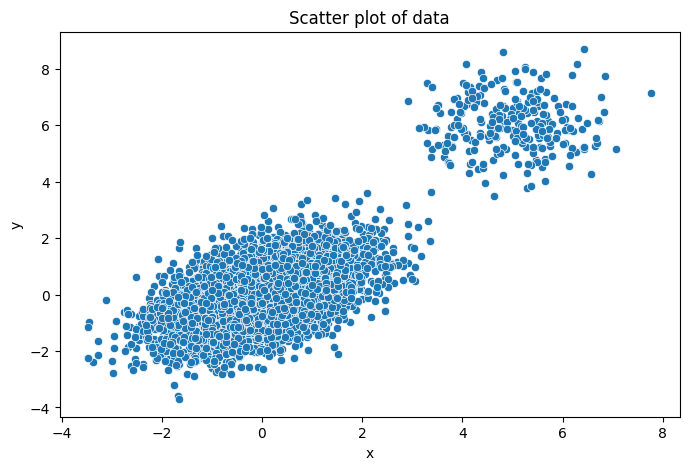

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=data,
    x='x',
    y='y',
)
plt.title('Scatter plot of data')
plt.show()

In [47]:
p = len(data.columns)
n = len(data)

### Mahalanobis Distance

In [48]:
from scipy.spatial import distance

mean = data.mean()
cov = data.cov()
inv_cov = np.linalg.inv(cov)
dM_squared = np.array([distance.mahalanobis(x, mean, inv_cov) for x in data.values]) ** 2

data['dM_squared'] = dM_squared

In [49]:
# Squared Mahalanobis distance follow Chi-squared distribution
# Estimated from samples, they follow Scaled Beta distribution or Scaled F-distribution

chi_squared_samples = np.random.chisquare(
    df=p, 
    size=n_samples
)

beta_samples =  ((n-1) ** 2 / n) * np.random.beta(
    a=p/2, 
    b=(n-p-1)/2,
    size=n_samples
)

f_samples = p * (n-1) * (n+1) / (n * (n-p)) * np.random.f(
    dfnum=p, 
    dfden=n-p, 
    size=n_samples
)

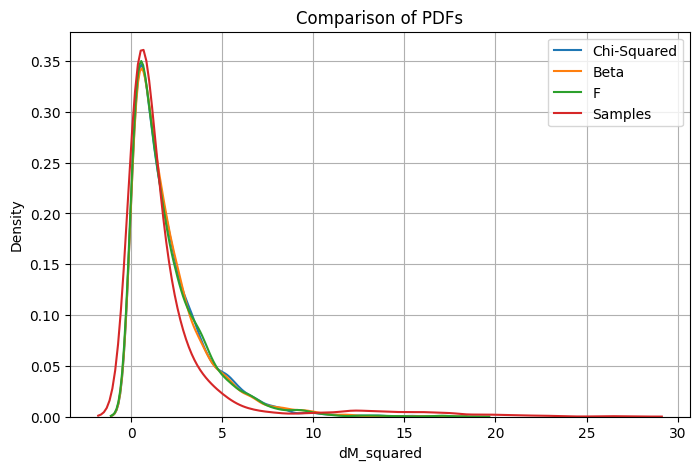

In [50]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=chi_squared_samples,
    label='Chi-Squared'
)
sns.kdeplot(
    data=beta_samples, 
    label='Beta'
)
sns.kdeplot(
    data=f_samples,
    label='F'
)
sns.kdeplot(
    data=data, 
    x='dM_squared', 
    label='Samples'
)

plt.title('Comparison of PDFs')
plt.legend()
plt.grid(True)
plt.show()

There is some deviation between theoretical distribution and sample distribution due to outliers.

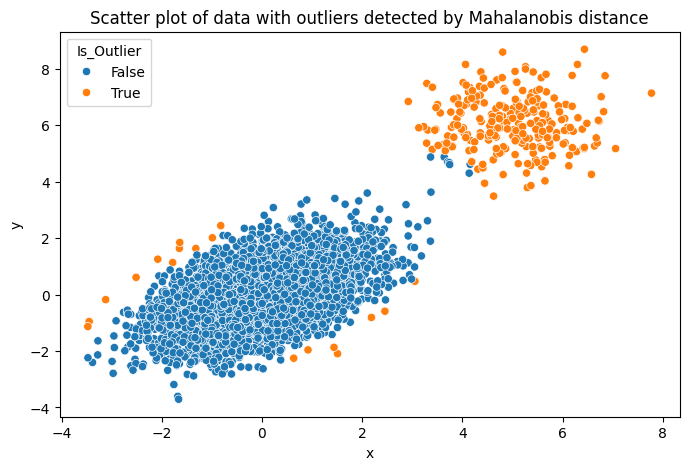

In [51]:
# Using Chi-squared distribution
from scipy.stats import chi2

df = len(data.columns)
quantile_filter = 0.95
dM_squared_threshold = chi2.ppf(quantile_filter, df)

data['Is_Outlier'] = data['dM_squared'] > dM_squared_threshold

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=data,
    x='x',
    y='y',
    hue='Is_Outlier'
)
plt.title('Scatter plot of data with outliers detected by Mahalanobis distance')
plt.show()

Mahalanobis distance detects global plus local outliers for major clusters. 
Note that the some outlier points have been wrongly classified as inliers.

In [52]:
data.drop(columns=['dM_squared', 'Is_Outlier'], inplace=True)

In [53]:
# sklearn.covariance provides robust estimates of location and scale parameters for multivariate distributions
from sklearn.covariance import MinCovDet

mcd = MinCovDet()
mcd.fit(data.values)

mean_robust = mcd.location_
cov_robust = mcd.covariance_

inv_cov_robust = np.linalg.inv(cov_robust)
dM_squared = np.array([distance.mahalanobis(x, mean_robust, inv_cov_robust) for x in data.values]) ** 2

data['dM_squared'] = dM_squared

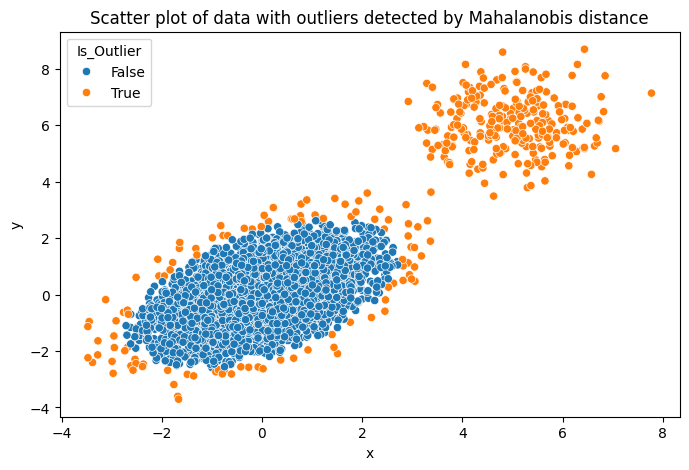

In [54]:
from scipy.stats import f

df = len(data.columns)
quantile_filter = 0.95
dM_squared_threshold = chi2.ppf(quantile_filter, df)

data['Is_Outlier'] = data['dM_squared'] > dM_squared_threshold

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=data,
    x='x',
    y='y',
    hue='Is_Outlier'
)
plt.title('Scatter plot of data with outliers detected by Mahalanobis distance')
plt.show()

Mahalanobis distance method using robust estimates outperforms normal method.

In [55]:
data.drop(columns=['dM_squared', 'Is_Outlier'], inplace=True)